In [1]:
# ============================================================
# CELL 1 -- CONFIG + SETUP
# ============================================================
# All settings here. Edit and re-run, then run cell 2+.
# ============================================================
import os, time, json, requests, subprocess, sys
import pandas as pd
from datetime import datetime
from tqdm.auto import tqdm
from IPython.display import display, HTML
import ipywidgets as widgets

# ── Paths ─────────────────────────────────────────────────────
DATA_DIR = "data/leads"
MASTER_CSV = f"{DATA_DIR}/leads_master.csv"
os.makedirs(DATA_DIR, exist_ok=True)

# ── Scrape settings ───────────────────────────────────────────
LOOKBACK_HOURS = 48
REDDIT_SLEEP = 2.2
PAGES = 5

SUBREDDITS = [
    # ── QRDive (Brick & Mortar Owners / Agencies) ──
    "restaurateur", "restaurantowners", "barowners", 
    "Dentistry", "AutoDetailing", "barbers", "salonowners", # "salonowners" instead of "hairsalon"
    "hotelowners", "AirBnB", 
    "LocalSEO", "Marketing", "Agency", # Agencies looking for tools for clients

    # ── Invoicor (Freelancers & Trades) ──
    "smallbusiness", "sweatystartup", "freelance", "freelanceWriters",
    "Contractor", "HVAC", "electricians", "plumbing", "landscaping",
    "photography", "videography", "webdesign", "graphic_design", 
    "copywriting", "Bookkeeping", "virtualassistants"
]

PRIMARY_KEYWORDS = [
    # ── QRDive (Reputation / Review Pain) ──
    "google review", "google reviews", "fake review", "bad review",
    "1 star review", "1-star review", "remove review",
    "ask for reviews", "asking for reviews", "get more reviews", 
    "qr code for reviews", "review software", "reputation management",
    "google business profile", "gmb ranking", "local seo tool",
    "birdeye", "podium", "nicejob", "gatherup", "trustpilot alternative",

    # ── Invoicor (Invoicing / Payment Pain) ──
    "invoice software", "invoicing app", "billing software",
    "how to bill", "send invoice", "payment link", 
    "chasing payment", "unpaid invoice", "client won't pay", 
    "late payment", "overdue invoice", "payment reminder",
    "quickbooks alternative", "freshbooks alternative", "wave accounting"
]

CONTEXT_KEYWORDS = [
    "recommend", "recommendation", "looking for", "need a", 
    "software", "app", "tool", "platform", "system",
    "automate", "automated", "automatic",
    "how do you", "what do you use", "what does everyone use",
    "alternative", "too expensive", "free", "pricing",
    "help", "advice", "struggling", "tired of", "annoying"
]

SKIP_KEYWORDS = [
    # ── Consumer/Employee Signals ──
    "my boss", "my manager", "the owner", "employer", 
    "my paycheck", "my wage", "salary", "shift",
    "as a customer", "i visited", "the waiter", "the receptionist", 
    "food was", "horrible service", "scammed me", "they charged me",
    "i bought", "my purchase", "refund",

    # ── B2B Spam & Irrelevant topics ──
    "buy reviews", "buy google reviews", "fake review service",
    "hiring", "job posting", "looking for work", "hire me",
    "crypto", "nft", "stock", "forex", "trading",
    "medical billing", "insurance billing", "medicare", # Different kind of billing
    "ama", "self promo", "i made $", "course", "masterclass"
]

TRACKING_COLS = {
    "replied": "no",
    "reply_date": "",
    "reply_url": "",
    "outcome": "",
    "notes": "",
}

# ── Helper: safely read master CSV with clean string cols ─────
def load_master():
    """Load master CSV with all string tracking cols cleaned."""
    if not os.path.exists(MASTER_CSV):
        return pd.DataFrame()
    df = pd.read_csv(MASTER_CSV)
    str_cols = ["replied", "outcome", "notes", "reply_date",
                "reply_url", "context_hits", "primary_hits", "tier"]
    for col in str_cols:
        if col in df.columns:
            df[col] = df[col].fillna("")
    return df

def save_master(df):
    """Save dataframe to master CSV."""
    df.to_csv(MASTER_CSV, index=False)

# ── Status ────────────────────────────────────────────────────
print(f"Config loaded.")
print(f"  {len(SUBREDDITS)} subreddits, {LOOKBACK_HOURS}h lookback")
print(f"  Master CSV: {MASTER_CSV}")
df_check = load_master()
if not df_check.empty:
    replied_n = (df_check["replied"] == "yes").sum()
    print(f"  Existing leads: {len(df_check)} ({replied_n} replied)")
else:
    print(f"  No existing leads (first run)")

Config loaded.
  28 subreddits, 48h lookback
  Master CSV: data/leads/leads_master.csv
  Existing leads: 183 (15 replied)


In [2]:
"""
Run this locally in your terminal or a notebook cell.
It fetches one subreddit RSS and prints exactly what the parser sees.
Paste the output back so we can fix the Cell 2 parser.
"""
import requests, xml.etree.ElementTree as ET, re, time

r = requests.get(
    "https://www.reddit.com/r/freelance/new/.rss?limit=25",
    headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"},
    timeout=15,
)
print(f"Status: {r.status_code}")
print(f"\n--- RAW XML (first 3000 chars) ---")
print(r.text[:3000])

print("\n\n--- PARSE ATTEMPT ---")
root = ET.fromstring(r.text)
print(f"Root tag: {root.tag}")

ns = {"a": "http://www.w3.org/2005/Atom"}
entries = root.findall("a:entry", ns)
print(f"Entries found (Atom ns): {len(entries)}")

entries_plain = root.findall(".//entry")
print(f"Entries found (no ns): {len(entries_plain)}")

items = root.findall(".//item")
print(f"Items found (RSS): {len(items)}")

# Print first entry in full
if entries:
    print("\n--- FIRST ENTRY (all children) ---")
    for child in entries[0]:
        print(f"  TAG: {child.tag}")
        print(f"  ATTRIB: {child.attrib}")
        print(f"  TEXT: {str(child.text or '')[:200]}")
        print()
elif entries_plain:
    print("\n--- FIRST ENTRY plain (all children) ---")
    for child in entries_plain[0]:
        print(f"  TAG: {child.tag}")
        print(f"  ATTRIB: {child.attrib}")
        print(f"  TEXT: {str(child.text or '')[:200]}")
        print()

Status: 200

--- RAW XML (first 3000 chars) ---
<?xml version="1.0" encoding="UTF-8"?><feed xmlns="http://www.w3.org/2005/Atom" xmlns:media="http://search.yahoo.com/mrss/"><category term="freelance" label="r/freelance"/><updated>2026-05-29T13:30:02+00:00</updated><icon>https://www.redditstatic.com/icon.png/</icon><id>/r/freelance/new/.rss?limit=25</id><link rel="self" href="https://www.reddit.com/r/freelance/new/.rss?limit=25" type="application/atom+xml" /><link rel="alternate" href="https://www.reddit.com/r/freelance/new/?limit=25" type="text/html" /><subtitle>Articles of interest for freelancers and people who want to become one. Violating the rules (https://old.reddit.com/r/freelance/about/rules) will cause your post/comment will be removed and you will be banned permanently.</subtitle><title>newest submissions : freelance</title><entry><author><name>/u/martey</name><uri>https://www.reddit.com/user/martey</uri></author><category term="freelance" label="r/freelance"/><content type="h

In [3]:
# ============================================================
# CELL 2 -- SCRAPE + APPEND NEW LEADS (RSS only, fixed)
# ============================================================

import xml.etree.ElementTree as ET
import random, re
import datetime as dt

NS = "http://www.w3.org/2005/Atom"  # Reddit uses this, confirmed

USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.4 Safari/605.1.15",
    "Mozilla/5.0 (X11; Linux x86_64; rv:125.0) Gecko/20100101 Firefox/125.0",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0",
]

def get_headers():
    return {"User-Agent": random.choice(USER_AGENTS), "DNT": "1"}

def t(tag):
    """Wrap tag name in Atom namespace."""
    return f"{{{NS}}}{tag}"

def fetch_and_parse(sub, cutoff):
    """Fetch RSS for sub, return list of filtered post dicts."""
    url = f"https://www.reddit.com/r/{sub}/new/.rss?limit=100"
    try:
        r = requests.get(url, headers=get_headers(), timeout=15)
    except Exception as e:
        tqdm.write(f"  ❌ r/{sub}: {type(e).__name__}")
        return []

    if r.status_code != 200:
        tqdm.write(f"  ❌ r/{sub}: HTTP {r.status_code}")
        return []

    try:
        root = ET.fromstring(r.text)
    except ET.ParseError as e:
        tqdm.write(f"  ❌ r/{sub}: XML parse error {e}")
        return []

    entries = root.findall(t("entry"))
    if not entries:
        tqdm.write(f"  ⚠️  r/{sub}: 0 entries in feed")
        return []

    posts = []
    for entry in entries:
        # All tags have {NS} prefix — confirmed from debug output
        title_el   = entry.find(t("title"))
        link_el    = entry.find(t("link"))
        content_el = entry.find(t("content"))
        updated_el = entry.find(t("updated")) or entry.find(t("published"))
        id_el      = entry.find(t("id"))

        title   = (title_el.text   or "").strip() if title_el   is not None else ""
        link    = link_el.get("href", "")          if link_el   is not None else ""
        content = (content_el.text or "").strip()  if content_el is not None else ""
        updated = (updated_el.text or "").strip()  if updated_el is not None else ""
        guid    = (id_el.text      or "").strip()  if id_el      is not None else ""

        if not title:
            continue

        # Parse timestamp
        try:
            ts = dt.datetime.fromisoformat(updated.replace("Z", "+00:00")).timestamp()
        except Exception:
            ts = time.time() - 3600

        if ts < cutoff:
            continue

        # Extract post ID — guid is "t3_POSTID" (confirmed)
        pid = guid.split("_")[-1] if "_" in guid else ""
        if not pid and "comments" in link:
            parts = link.rstrip("/").split("/")
            idx = parts.index("comments")
            pid = parts[idx + 1] if idx + 1 < len(parts) else ""
        if not pid:
            continue

        # Strip HTML from body
        body = re.sub(r"<[^>]+>", " ", content)
        body = re.sub(r"&[a-z#0-9]+;", " ", body)  # decode HTML entities roughly
        body = re.sub(r"\s+", " ", body).strip()

        posts.append({
            "id":           pid,
            "title":        title,
            "body":         body[:600],
            "permalink":    link,
            "created_utc":  ts,
        })

    return posts


# ── Main loop ─────────────────────────────────────────────────
existing_ids = set()
df_existing = load_master()
if not df_existing.empty and "post_id" in df_existing.columns:
    existing_ids = set(df_existing["post_id"].astype(str).values)
    print(f"Skipping {len(existing_ids)} known posts")

cutoff    = time.time() - (LOOKBACK_HOURS * 3600)
seen      = set()
new_leads = []
ok = fail = 0

for sub in tqdm(SUBREDDITS, desc="Scanning"):
    posts = fetch_and_parse(sub, cutoff)

    if posts:
        ok += 1
    else:
        fail += 1

    for d in posts:
        pid = d["id"]
        if pid in seen or pid in existing_ids:
            continue
        seen.add(pid)

        full = f"{d['title']} {d['body']}".lower()
        if any(skip in full for skip in SKIP_KEYWORDS):
            continue

        primary_hits = [kw for kw in PRIMARY_KEYWORDS if kw in full]
        if not primary_hits:
            continue

        context_hits = [kw for kw in CONTEXT_KEYWORDS if kw in full]
        score = len(primary_hits) * 10 + len(context_hits) * 5
        hours_ago = round((time.time() - d["created_utc"]) / 3600, 1)

        tier = (
            "hot"   if hours_ago <= 12 and score >= 15 else
            "warm"  if hours_ago <= 24 and score >= 10 else
            "older"
        )

        lead = {
            "post_id":      pid,
            "scrape_date":  datetime.now().strftime("%Y-%m-%d %H:%M"),
            "score":        score,
            "tier":         tier,
            "subreddit":    sub,
            "title":        d["title"],
            "body_preview": d["body"],
            "url":          d["permalink"],
            "upvotes":      0,
            "comments":     0,
            "hours_ago":    hours_ago,
            "primary_hits": ", ".join(primary_hits),
            "context_hits": ", ".join(context_hits),
            "source":       "rss",
        }
        for col, default in TRACKING_COLS.items():
            lead[col] = default
        new_leads.append(lead)

    time.sleep(random.uniform(1.0, 2.2))

# ── Save ──────────────────────────────────────────────────────
df_new    = pd.DataFrame(new_leads) if new_leads else pd.DataFrame()
df_master = load_master()

if not df_new.empty:
    df_master = pd.concat([df_master, df_new], ignore_index=True) if not df_master.empty else df_new
    df_master = df_master.drop_duplicates(subset="post_id", keep="first")
    save_master(df_master)

total = len(df_master) if not df_master.empty else 0
print(f"\n{'='*60}")
print(f" NEW: {len(df_new)} | TOTAL: {total}")
print(f" Subreddits — ok: {ok} | failed: {fail}")
print(f" Saved: {MASTER_CSV}")
print(f"{'='*60}")

Skipping 183 known posts


Scanning:   0%|          | 0/28 [00:00<?, ?it/s]

/var/folders/yj/2dw3syk175145_7bts9_4vqr0000gn/T/ipykernel_20381/2565273557.py:55: DeprecationWarning: Testing an element's truth value will always return True in future versions.  Use specific 'len(elem)' or 'elem is not None' test instead.
  updated_el = entry.find(t("updated")) or entry.find(t("published"))



 NEW: 7 | TOTAL: 190
 Subreddits — ok: 22 | failed: 6
 Saved: data/leads/leads_master.csv


In [6]:
# ============================================================
# CELL 3 -- INTERACTIVE LEAD DASHBOARD
# ============================================================
# Shows leads sorted: HOT first, then WARM, then OLDER.
# Each lead has: Open & Reply, Save Notes, Skip buttons.
# "Open & Reply" opens the URL and auto-marks replied + date.
# ============================================================

df = load_master()

# Sort: unreplied first, then by tier priority, then score
tier_order = {"hot": 0, "warm": 1, "older": 2}
df["_tier_sort"] = df["tier"].map(tier_order).fillna(3)
df["_replied_sort"] = df["replied"].apply(lambda x: 1 if x == "yes" else (2 if x == "skip" else 0))
df = df.sort_values(
    ["_replied_sort", "_tier_sort", "score"],
    ascending=[True, True, False]
).reset_index(drop=True)

# Stats
total = len(df)
replied_n = (df["replied"] == "yes").sum()
skipped_n = (df["replied"] == "skip").sum()
unreplied_n = total - replied_n - skipped_n

print(f"Total: {total} | Replied: {replied_n} | Skipped: {skipped_n} | Unreplied: {unreplied_n}")
print(f"{'='*60}\n")

# Only show unreplied
show_df = df[
    (df["replied"] == "no")
    & (df["outcome"] == "")
    & (df["notes"] == "")
].head(20)

if show_df.empty:
    print("No unreplied leads. Run cell 2 to scrape new ones.")
else:
    def make_card(row):
        tier_colors = {"hot": "#e74c3c", "warm": "#f39c12", "older": "#95a5a6"}
        tc = tier_colors.get(row["tier"], "#95a5a6")

        header = widgets.HTML(
            f'<span style="background:{tc};color:white;padding:2px 8px;'
            f'border-radius:3px;font-size:11px">{row["tier"].upper()}</span> '
            f'<b>[{row["score"]}]</b> r/{row["subreddit"]} | '
            f'^{row["upvotes"]} | {row["comments"]}c | {row["hours_ago"]}h ago'
        )
        title = widgets.HTML(
            f'<div style="font-size:14px;margin:4px 0">{row["title"][:100]}</div>'
        )
        kw_text = f'Primary: {row["primary_hits"]}'
        ctx = row.get("context_hits", "")
        if ctx:
            kw_text += f'  |  Context: {ctx[:50]}'
        keywords = widgets.HTML(f'<div style="font-size:11px;color:#666">{kw_text}</div>')

        notes_input = widgets.Text(
            value=str(row.get("notes", "")),
            placeholder="Add notes...",
            layout=widgets.Layout(width="350px"),
        )
        outcome_dd = widgets.Dropdown(
            options=["", "replied", "upvoted", "dm", "Helpfull", "ignored"],
            value=str(row.get("outcome", "")),
            layout=widgets.Layout(width="110px"),
        )

        reply_btn = widgets.Button(description="Open", button_style="success",
                                   layout=widgets.Layout(width="80px"))
        save_btn = widgets.Button(description="Save", button_style="info",
                                  layout=widgets.Layout(width="70px"))
        skip_btn = widgets.Button(description="Skip", button_style="warning",
                                  layout=widgets.Layout(width="70px"))
        status = widgets.HTML("")

        pid = str(row["post_id"])
        url = row["url"]

        def _update_csv(updates):
            df_f = load_master()
            mask = df_f["post_id"].astype(str) == pid
            for k, v in updates.items():
                df_f.loc[mask, k] = v
            save_master(df_f)

        def on_reply(_):
            try:
                if sys.platform == "darwin":
                    subprocess.Popen(["open", url])
                elif sys.platform == "win32":
                    subprocess.Popen(["start", url], shell=True)
                else:
                    subprocess.Popen(["xdg-open", url])
            except Exception:
                pass
            status.value = '<span style="color:gray">Opened</span>'

        def on_save(_):
            if not outcome_dd.value:
                status.value = '<span style="color:red">Pick an outcome first</span>'
                return
            updates = {
                "notes": notes_input.value,
                "outcome": outcome_dd.value,
            }
            if outcome_dd.value in ("replied", "dm"):
                updates["replied"] = "yes"
                updates["reply_date"] = datetime.now().strftime("%Y-%m-%d")
            elif outcome_dd.value == "ignored":
                updates["replied"] = "skip"
            _update_csv(updates)
            reply_btn.disabled = True
            skip_btn.disabled = True
            save_btn.disabled = True
            status.value = f'<span style="color:green">Saved: {outcome_dd.value}</span>'

        def on_skip(_):
            _update_csv({
                "replied": "skip",
                "outcome": "skip",
                "notes": notes_input.value,
            })
            reply_btn.disabled = True
            skip_btn.disabled = True
            status.value = '<span style="color:orange">Skipped</span>'

        reply_btn.on_click(on_reply)
        save_btn.on_click(on_save)
        skip_btn.on_click(on_skip)

        row_btns = widgets.HBox([
            reply_btn, save_btn, skip_btn,
            widgets.Label("Notes:"), notes_input,
            widgets.Label("Outcome:"), outcome_dd,
            status,
        ])

        return widgets.VBox(
            [header, title, keywords, row_btns],
            layout=widgets.Layout(
                border="1px solid #ddd", padding="10px",
                margin="5px 0", border_radius="5px",
            ),
        )

    print(f"Showing {len(show_df)} unreplied leads (best first):\n")
    for _, row in show_df.iterrows():
        display(make_card(row))

Total: 190 | Replied: 19 | Skipped: 143 | Unreplied: 28

Showing 20 unreplied leads (best first):



In [7]:
# ============================================================
# CELL 4 -- TABLE VIEW (all leads, scrollable)
# ============================================================
# Read-only table. Hot = yellow, warm = blue, replied = faded.
# URLs are clickable "open" links.
# ============================================================

df = load_master()

display_cols = [
    "tier", "score", "replied", "outcome",
    "subreddit", "title", "upvotes", "comments",
    "hours_ago", "scrape_date", "reply_date", "notes",
    "url", "post_id",
]
display_cols = [c for c in display_cols if c in df.columns]

tier_order = {"hot": 0, "warm": 1, "older": 2}
df["_sort"] = df["tier"].map(tier_order).fillna(3)
df_view = df[display_cols + ["_sort"]].sort_values(
    ["_sort", "score"], ascending=[True, False]
).drop(columns=["_sort"])

# Clickable URLs
if "url" in df_view.columns:
    df_view = df_view.copy()
    df_view["url"] = df_view["url"].apply(
        lambda u: f'<a href="{u}" target="_blank">open</a>' if isinstance(u, str) else ""
    )

def color_rows(row):
    replied_val = str(row.get("replied", ""))
    tier_val = str(row.get("tier", ""))
    if replied_val == "yes":
        return ["opacity: 0.4;"] * len(row)
    elif replied_val == "skip":
        return ["opacity: 0.5;"] * len(row)
    elif tier_val == "hot":
        return ["background-color: #fff3cd;"] * len(row)
    elif tier_val == "warm":
        return ["background-color: #f0f9ff;"] * len(row)
    return [""] * len(row)

styled = (
    df_view.style
    .apply(color_rows, axis=1)
    .set_properties(**{"font-size": "12px", "text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("font-size", "11px")]},
    ])
)

replied_n = (df["replied"] == "yes").sum()
skipped_n = (df["replied"] == "skip").sum()
print(f"All leads: {len(df)} | Replied: {replied_n} | Skipped: {skipped_n}")
display(HTML(styled.to_html(escape=False)))

All leads: 190 | Replied: 19 | Skipped: 144


,tier,score,replied,outcome,subreddit,title,upvotes,comments,hours_ago,scrape_date,reply_date,notes,url,post_id
97,hot,110,skip,skip,AirBnB,Host called 911 after we arrived at 4am from the hospital on the second night [US],51,140,4.300000,2026-05-21 20:01,,,open,1tjl0x2
159,hot,100,skip,skip,electricians,Just fixing my leads job...,132,63,1.400000,2026-05-21 20:03,,,open,1tjq4rg
46,hot,92,skip,skip,ecommerce,I've been using Claude Code for the past month to build stuff I'd otherwise have to pay a monthly fee for,32,23,7.100000,2026-05-12 14:12,,,open,1taro12
18,hot,90,no,replied,ecommerce,Paypal freezes 45K right before payroll and support keeps saying investigate,20,47,9.300000,2026-05-11 19:10,,Just Dont like it,open,1t9wgj5
108,hot,90,skip,skip,LocalSEO,I've been doing local SEO for two years – here's what actually moves the needle,0,24,10.000000,2026-05-21 20:02,,,open,1tjdqaw
21,hot,88,no,ignored,plumbing,Can we have some type of ban on posts from software developers fishing for information or fishing for interest in their programs?,120,14,4.600000,2026-05-11 19:23,,,open,1ta29es
41,hot,84,skip,skip,graphic_design,Difficult client wants InDesign files before paying the final invoice,9,22,1.000000,2026-05-12 14:11,,,open,1tayd71
30,hot,63,skip,skip,smallbusiness,Stuck on legacy systems at $3M revenue with 10 staff — what does sensible modernisation actually look like?,8,21,9.100000,2026-05-12 14:10,,,open,1tap1s9
124,hot,61,skip,skip,smallbusiness,How do you deal with clients who find issues with everything?,17,12,1.100000,2026-05-21 20:02,,,open,1tjql7z
171,hot,59,skip,skip,bookkeeping,How do you handle clients who promise things in chat/text but forget to log it in the actual system?,0,17,4.300000,2026-05-21 20:04,,,open,1tjl3ot


In [8]:
# ============================================================
# CELL 5 -- REPLY STATS
# ============================================================

df = load_master()

total = len(df)
replied_df = df[df["replied"] == "yes"]
skipped_df = df[df["replied"] == "skip"]
unreplied = total - len(replied_df) - len(skipped_df)

print(f"{'='*60}")
print(f" STATS")
print(f"{'='*60}")
print(f"  Total:     {total}")
print(f"  Replied:   {len(replied_df)}")
print(f"  Skipped:   {len(skipped_df)}")
print(f"  Unreplied: {unreplied}")
if total > 0:
    print(f"  Reply rate: {len(replied_df)/total*100:.0f}%")

if len(replied_df) > 0:
    print(f"\n  By subreddit:")
    for sub, n in replied_df["subreddit"].value_counts().items():
        print(f"    r/{sub:22s} {n}")

    outcomes = replied_df[replied_df["outcome"] != ""]["outcome"].value_counts()
    if not outcomes.empty:
        print(f"\n  Outcomes:")
        for o, n in outcomes.items():
            print(f"    {o:15s} {n}")

    print(f"\n  By tier:")
    for tier in ["hot", "warm", "older"]:
        tier_replied = (replied_df["tier"] == tier).sum()
        tier_total = (df["tier"] == tier).sum()
        if tier_total > 0:
            print(f"    {tier:10s} {tier_replied:3d} / {tier_total} ({tier_replied/tier_total*100:.0f}%)")

    dates = replied_df[replied_df["reply_date"] != ""]["reply_date"].value_counts().sort_index()
    if not dates.empty:
        print(f"\n  Recent activity:")
        for d, n in dates.tail(7).items():
            print(f"    {d}: {n} replies")
else:
    print("\n  No replies yet. Use cell 3 to start replying.")

 STATS
  Total:     190
  Replied:   19
  Skipped:   144
  Unreplied: 27
  Reply rate: 10%

  By subreddit:
    r/smallbusiness          13
    r/LocalSEO               3
    r/plumbing               1
    r/landscaping            1
    r/restaurantowners       1

  Outcomes:
    replied         18
    dm              1

  By tier:
    hot          8 / 68 (12%)
    warm         9 / 63 (14%)
    older        2 / 59 (3%)

  Recent activity:
    2026-05-11: 6 replies
    2026-05-21: 1 replies
    2026-05-27: 8 replies
    2026-05-29: 4 replies


In [9]:
# ============================================================
# CELL 6 -- MANUAL UPDATE (if buttons don't work)
# ============================================================
# Edit the fields below, run the cell. Fallback for when
# ipywidgets buttons aren't available (e.g. remote Jupyter).
# ============================================================

POST_ID    = ""          # paste post_id here
REPLIED    = "yes"       # yes / skip / no
REPLY_DATE = ""          # empty = today
REPLY_URL  = ""          # optional
OUTCOME    = ""          # replied / dm / signup / ignored / skip
NOTES      = ""          # your notes

if not POST_ID:
    print("Paste a post_id above and re-run.")
else:
    df = load_master()
    mask = df["post_id"].astype(str) == str(POST_ID)
    if mask.sum() == 0:
        print(f"Post ID '{POST_ID}' not found.")
    else:
        df.loc[mask, "replied"] = REPLIED
        df.loc[mask, "reply_date"] = REPLY_DATE or datetime.now().strftime("%Y-%m-%d")
        if REPLY_URL:
            df.loc[mask, "reply_url"] = REPLY_URL
        if OUTCOME:
            df.loc[mask, "outcome"] = OUTCOME
        if NOTES:
            df.loc[mask, "notes"] = NOTES
        save_master(df)
        row = df.loc[mask].iloc[0]
        print(f"Updated: {row['title'][:60]}")
        print(f"  replied={row['replied']} | date={row['reply_date']} | outcome={row['outcome']}")

Paste a post_id above and re-run.


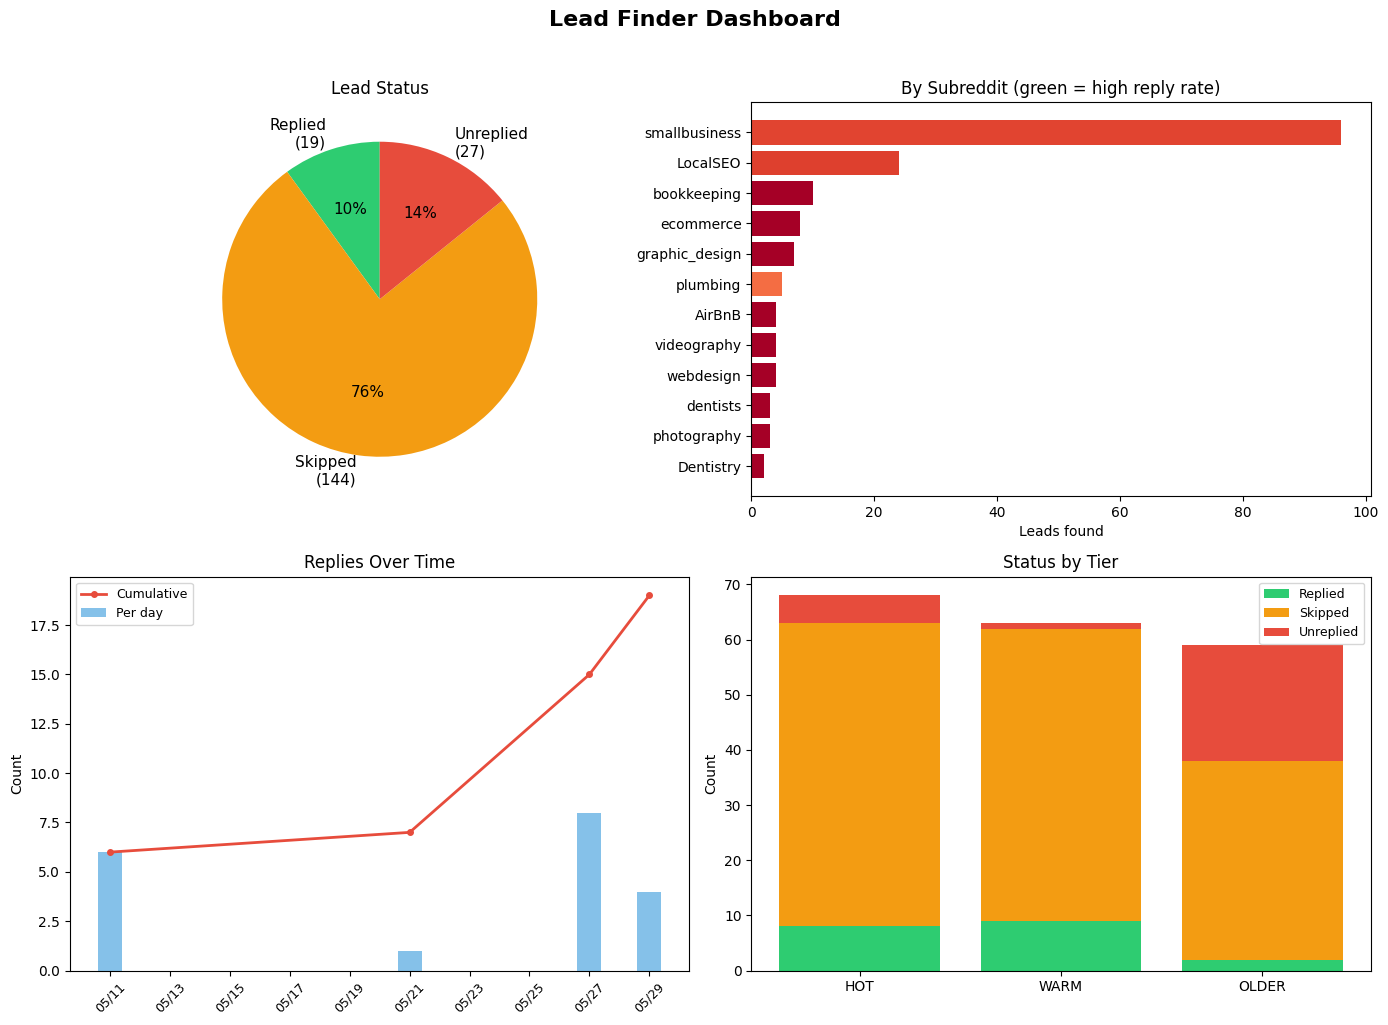


  Total: 190 | Replied: 19 | Rate: 10%
  Outcomes: {'skip': 137, 'replied': 19, 'ignored': 8, 'Helpfull': 6, 'dm': 1}


In [10]:
# ============================================================
# CELL 7 -- VISUAL STATS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = load_master()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Lead Finder Dashboard", fontsize=16, fontweight="bold", y=1.02)

# ── 1. Status breakdown (pie) ────────────────────────────────
ax1 = axes[0, 0]
status_counts = {
    "Replied": (df["replied"] == "yes").sum(),
    "Skipped": (df["replied"] == "skip").sum(),
    "Unreplied": (~df["replied"].isin(["yes", "skip"])).sum(),
}
colors_pie = ["#2ecc71", "#f39c12", "#e74c3c"]
vals = [v for v in status_counts.values()]
lbls = [f"{k}\n({v})" for k, v in status_counts.items()]
if sum(vals) > 0:
    ax1.pie(vals, labels=lbls, colors=colors_pie, autopct="%1.0f%%",
            startangle=90, textprops={"fontsize": 11})
ax1.set_title("Lead Status")

# ── 2. Leads by subreddit (horizontal bar) ───────────────────
ax2 = axes[0, 1]
sub_counts = df["subreddit"].value_counts().head(12)
colors_bar = []
for sub in sub_counts.index:
    sub_df = df[df["subreddit"] == sub]
    replied_pct = (sub_df["replied"] == "yes").sum() / len(sub_df) if len(sub_df) > 0 else 0
    colors_bar.append(plt.cm.RdYlGn(replied_pct))

ax2.barh(sub_counts.index[::-1], sub_counts.values[::-1], color=colors_bar[::-1])
ax2.set_xlabel("Leads found")
ax2.set_title("By Subreddit (green = high reply rate)")
ax2.tick_params(axis="y", labelsize=10)

# ── 3. Replies over time (line) ──────────────────────────────
ax3 = axes[1, 0]
replied_df = df[df["replied"] == "yes"].copy()
if not replied_df.empty and (replied_df["reply_date"] != "").any():
    dates = replied_df[replied_df["reply_date"] != ""]["reply_date"]
    date_counts = dates.value_counts().sort_index()
    cumulative = date_counts.cumsum()

    x = pd.to_datetime(date_counts.index)
    ax3.bar(x, date_counts.values, color="#3498db", alpha=0.6, label="Per day")
    ax3.plot(x, cumulative.values, color="#e74c3c", linewidth=2, marker="o",
             markersize=4, label="Cumulative")
    ax3.legend(fontsize=9)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    ax3.tick_params(axis="x", rotation=45, labelsize=9)
else:
    ax3.text(0.5, 0.5, "No replies yet", ha="center", va="center",
             fontsize=12, color="#999", transform=ax3.transAxes)
ax3.set_title("Replies Over Time")
ax3.set_ylabel("Count")

# ── 4. Tier + outcome breakdown (stacked bar) ────────────────
ax4 = axes[1, 1]
tier_data = {}
for tier in ["hot", "warm", "older"]:
    t = df[df["tier"] == tier]
    tier_data[tier] = {
        "Replied": (t["replied"] == "yes").sum(),
        "Skipped": (t["replied"] == "skip").sum(),
        "Unreplied": (~t["replied"].isin(["yes", "skip"])).sum(),
    }

tiers = list(tier_data.keys())
replied_vals = [tier_data[t]["Replied"] for t in tiers]
skipped_vals = [tier_data[t]["Skipped"] for t in tiers]
unreplied_vals = [tier_data[t]["Unreplied"] for t in tiers]

x_pos = range(len(tiers))
ax4.bar(x_pos, replied_vals, color="#2ecc71", label="Replied")
ax4.bar(x_pos, skipped_vals, bottom=replied_vals, color="#f39c12", label="Skipped")
ax4.bar(x_pos, unreplied_vals,
        bottom=[r + s for r, s in zip(replied_vals, skipped_vals)],
        color="#e74c3c", label="Unreplied")
ax4.set_xticks(x_pos)
ax4.set_xticklabels([t.upper() for t in tiers])
ax4.legend(fontsize=9)
ax4.set_title("Status by Tier")
ax4.set_ylabel("Count")

plt.tight_layout()
plt.show()

# ── Summary numbers ───────────────────────────────────────────
total = len(df)
replied_n = (df["replied"] == "yes").sum()
print(f"\n{'='*60}")
print(f"  Total: {total} | Replied: {replied_n} | Rate: {replied_n/total*100:.0f}%" if total > 0 else "  No data yet")
if replied_n > 0:
    outcomes = df[df["outcome"] != ""]["outcome"].value_counts()
    if not outcomes.empty:
        print(f"  Outcomes: {dict(outcomes)}")
print(f"{'='*60}")